# Persistence Concept Implementation Workflow

In [ ]:
"""
START --> Genearte_Joke(LLM) --> Explain_Joke(LLM) --> END
"""

In [27]:
from langgraph.graph import StateGraph, START , END
from typing import TypedDict , Annotated
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver  # (RAM)

In [28]:
load_dotenv()
model = ChatOpenAI()

In [29]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [30]:
def generate_joke(state: JokeState):
    prompt = f"Generate a Joke on the topic {state['topic']}"
    response = model.invoke(prompt).content
    return {"joke":response}

In [31]:
def explanation_joke(state: JokeState):
    prompt = f"Explain the following joke in most simple wording {state['joke']}"
    response = model.invoke(prompt)
    return {"explanation":response}

In [39]:
graph = StateGraph(JokeState)

graph.add_node("generate_joke",generate_joke)
graph.add_node("explanation_joke",explanation_joke)

graph.add_edge(START,"generate_joke")
graph.add_edge("generate_joke","explanation_joke")
graph.add_edge("explanation_joke",END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

In [40]:
config = {"configurable":{"thread_id":"1"}}

initial_state = {"topic":"pizza"}

final_state = workflow.invoke(initial_state,config=config)

final_state

{'topic': 'pizza',
 'joke': "Why did the pizza go to therapy?  \nBecause it had too many toppings and couldn't hold it all together!",
 'explanation': AIMessage(content='The pizza went to therapy because it had too many toppings and was falling apart.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 39, 'total_tokens': 55, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-EDs9CTKyNUqnJZDNgHf0ezPTp2Gy0', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01297-42a5-7272-813c-786a2f4a9833-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 39, 'output_tokens': 16, 'total_tokens':

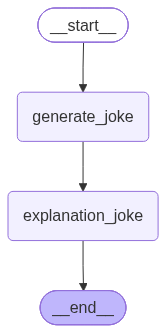

In [41]:
workflow

In [42]:
# Final state values
workflow.get_state(config=config)

StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza go to therapy?  \nBecause it had too many toppings and couldn't hold it all together!", 'explanation': AIMessage(content='The pizza went to therapy because it had too many toppings and was falling apart.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 39, 'total_tokens': 55, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-EDs9CTKyNUqnJZDNgHf0ezPTp2Gy0', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01297-42a5-7272-813c-786a2f4a9833-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 39, 'output_tokens': 

In [43]:
list(workflow.get_state_history(config=config))

[StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza go to therapy?  \nBecause it had too many toppings and couldn't hold it all together!", 'explanation': AIMessage(content='The pizza went to therapy because it had too many toppings and was falling apart.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 39, 'total_tokens': 55, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-EDs9CTKyNUqnJZDNgHf0ezPTp2Gy0', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01297-42a5-7272-813c-786a2f4a9833-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 39, 'output_tokens':

In [44]:
config_1 = {"configurable":{"thread_id":"2"}}

initial_state = {"topic":"Abdul Moiz"}

final_state = workflow.invoke(initial_state,config=config_1)

final_state

{'topic': 'Abdul Moiz',
 'joke': 'Why did Abdul Moiz bring a ladder to the comedy show? Because he heard it was a high-brow event!',
 'explanation': AIMessage(content='Abdul Moiz brought a ladder to the comedy show because he thought it was a fancy and sophisticated event. In other words, he thought it was going to be a "high-brow" event, meaning it would be classy or exclusive.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 40, 'total_tokens': 90, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-EDs9VXnyfjJKgCbhOJEVlDaKaDDeG', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01297-8dfa-78a3-9f

In [48]:
# Final state values
workflow.get_state(config=config)

StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza go to therapy?  \nBecause it had too many toppings and couldn't hold it all together!", 'explanation': AIMessage(content='The pizza went to therapy because it had too many toppings and was falling apart.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 39, 'total_tokens': 55, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-EDs9CTKyNUqnJZDNgHf0ezPTp2Gy0', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01297-42a5-7272-813c-786a2f4a9833-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 39, 'output_tokens': 

In [49]:
# Final state values
workflow.get_state(config=config_1)

StateSnapshot(values={'topic': 'Abdul Moiz', 'joke': 'Why did Abdul Moiz bring a ladder to the comedy show? Because he heard it was a high-brow event!', 'explanation': AIMessage(content='Abdul Moiz brought a ladder to the comedy show because he thought it was a fancy and sophisticated event. In other words, he thought it was going to be a "high-brow" event, meaning it would be classy or exclusive.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 40, 'total_tokens': 90, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-EDs9VXnyfjJKgCbhOJEVlDaKaDDeG', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01